<a href="https://colab.research.google.com/github/Mahian-Hoq/ml-notebooks-from-scratch/blob/main/HeartDisease_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Environment Setup

Here I have imported necessary libraries and setted matplotlib's style and Seaborn's font size

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set(font_scale= 1.1)

from google.colab import files

##File use

Here The Heart.csv file should be uploaded from kaggle.

So to use this ipynb you have to download the dataset from Kaggle.

In [ ]:
uploaded = files.upload()

df = pd.read_csv("heart.csv")

df.head()

Saving heart.csv to heart.csv


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


---

#EDA

Here I will explore the Heart.csv dataframe.

In [ ]:
print("Shape", df.shape)

Shape (918, 12)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Here we can see
> There is no null values as every column has 918 values.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [ ]:
target_col = "HeartDisease"
numeric_cols = ['Age', 'RestingBP','Cholesterol','FastingBS', 'MaxHR', 'Oldpeak']

categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

In [ ]:
df[numeric_cols].agg(["min", "max", "mean", "median"]).T

,min,max,mean,median
Age,28.0,77.0,53.510893,54.0
RestingBP,0.0,200.0,132.396514,130.0
Cholesterol,0.0,603.0,198.799564,223.0
FastingBS,0.0,1.0,0.233115,0.0
MaxHR,60.0,202.0,136.809368,138.0
Oldpeak,-2.6,6.2,0.887364,0.6


From here We can see that the Mean of **Cholesterol** is not near of its Median.

Indicates,
> **Cholesterol** is left skewed and it has some Outliers.

We also see there are 0 values in min of **RestingBP and Cholesterol**. Which is not possible.

Indicates,
> RestingBP and Cholesterol has missing values which are replaced by 0.

In [ ]:
for c in categorical_cols:
  print(c, df[c].unique())

Sex ['M' 'F']
ChestPainType ['ATA' 'NAP' 'ASY' 'TA']
RestingECG ['Normal' 'ST' 'LVH']
ExerciseAngina ['N' 'Y']
ST_Slope ['Up' 'Flat' 'Down']


---

##Review the Nummerical Cols with Histogram

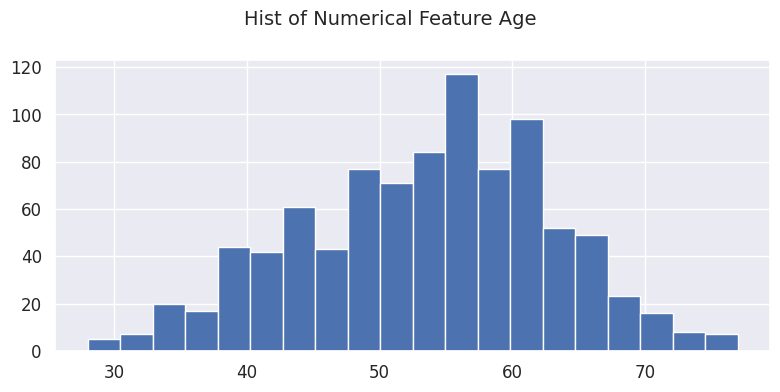

In [ ]:
df['Age'].hist(bins= 20, figsize = (8,4))
plt.suptitle("Hist of Numerical Feature Age", fontsize = 14)
plt.tight_layout()
plt.show()

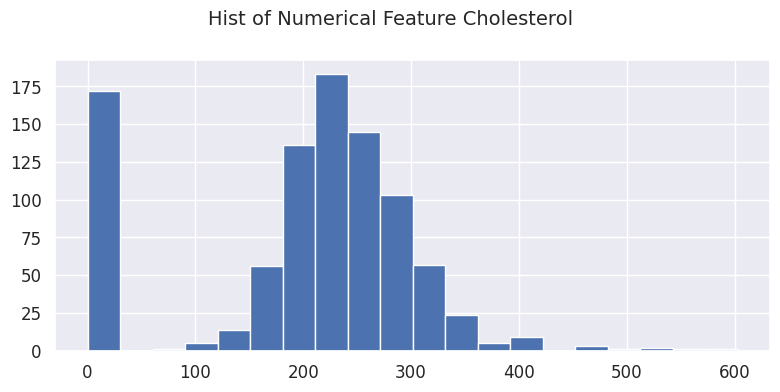

In [ ]:
df['Cholesterol'].hist(bins= 20, figsize = (8,4))
plt.suptitle("Hist of Numerical Feature Cholesterol", fontsize = 14)
plt.tight_layout()
plt.show()

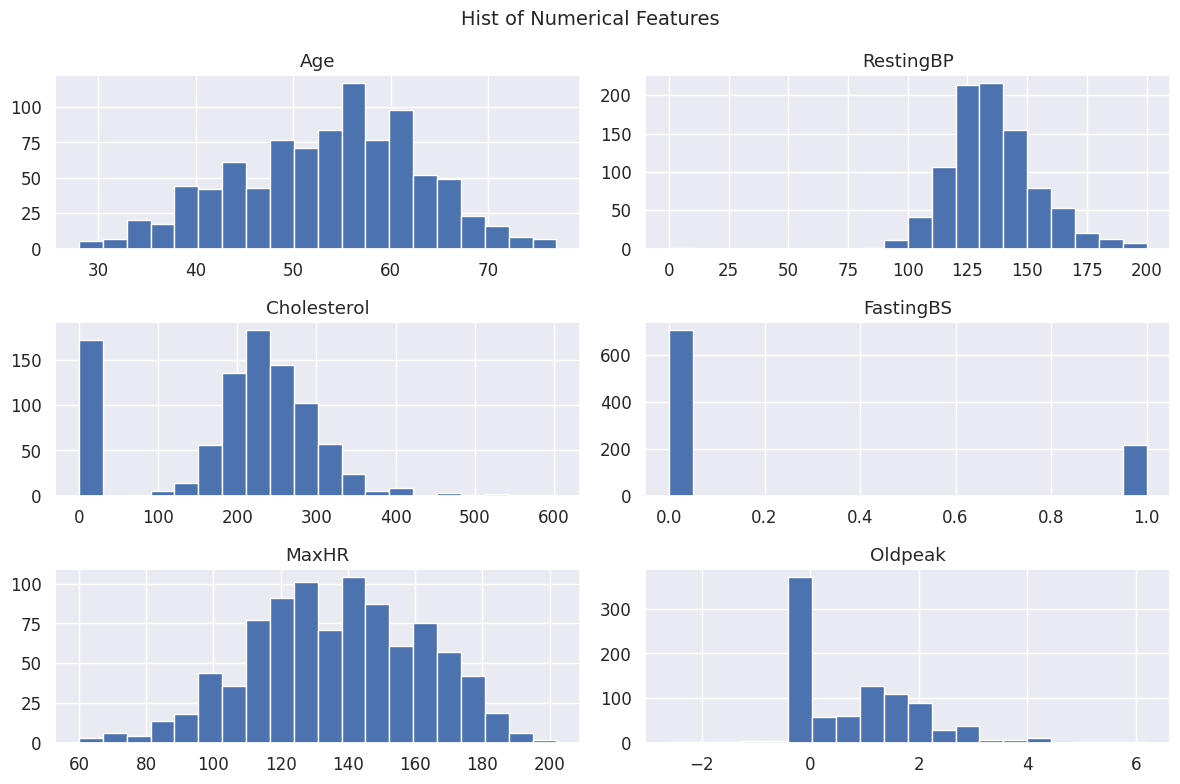

In [ ]:
df[numeric_cols].hist(bins= 20, figsize = (12,8))
plt.suptitle("Hist of Numerical Features", fontsize = 14)
plt.tight_layout()
plt.show()

---

##Review the Numerical Cols by BoxPlot

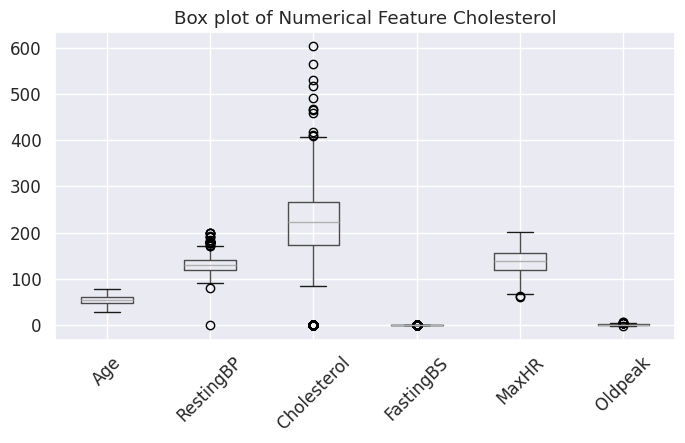

In [ ]:
plt.figure(figsize = (8,4))
df[numeric_cols].boxplot()
plt.title("Box plot of Numerical Feature Cholesterol")
plt.xticks(rotation = 45)
plt.show()

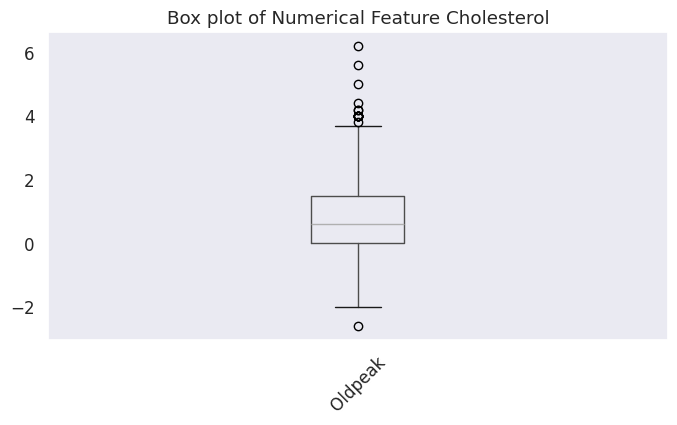

In [ ]:
plt.figure(figsize = (8,4))
df[['Oldpeak']].boxplot()
plt.title("Box plot of Numerical Feature Cholesterol")
plt.xticks(rotation = 45)
plt.grid(0)
plt.show()

---

##Analysing The Target Column

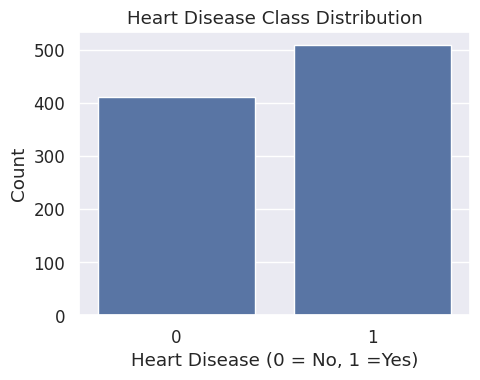

In [ ]:
plt.figure(figsize = (5,4))
sns.countplot(x=df[target_col])
plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease (0 = No, 1 =Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
df[target_col].value_counts(normalize = True)

,proportion
HeartDisease,
1,0.553377
0,0.446623


---

##Evaluating the Categorical Columns

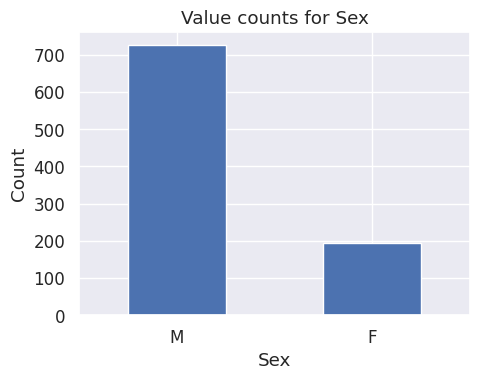

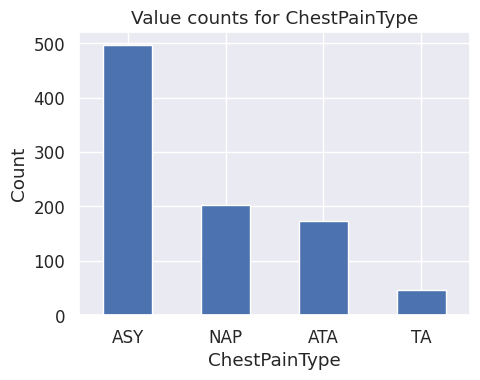

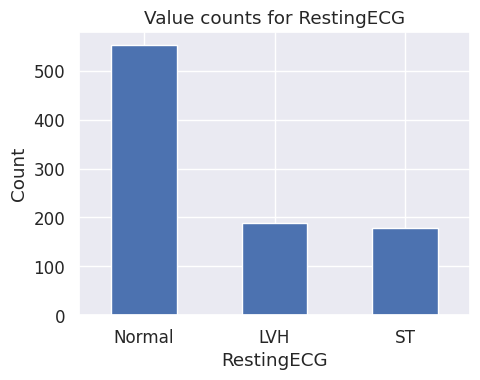

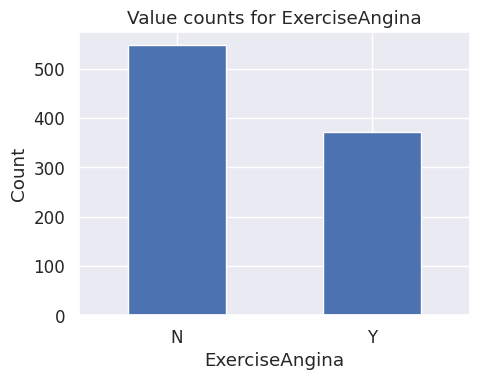

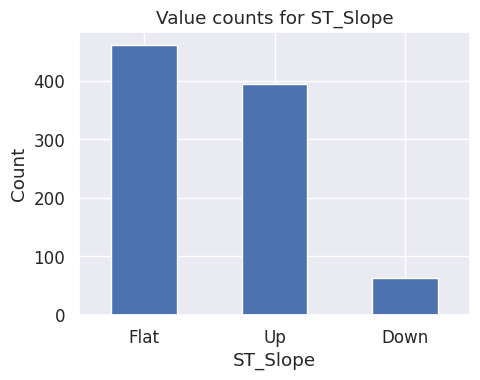

In [ ]:
for c in categorical_cols:
  plt.figure(figsize = (5,4))
  df[c].value_counts().plot(kind = "bar", title = c)
  plt.title(f"Value counts for {c}")
  plt.ylabel("Count")
  plt.xticks(rotation = 0)
  plt.tight_layout()
  plt.show()

---

##Relation between Categorical Columns and Target Column

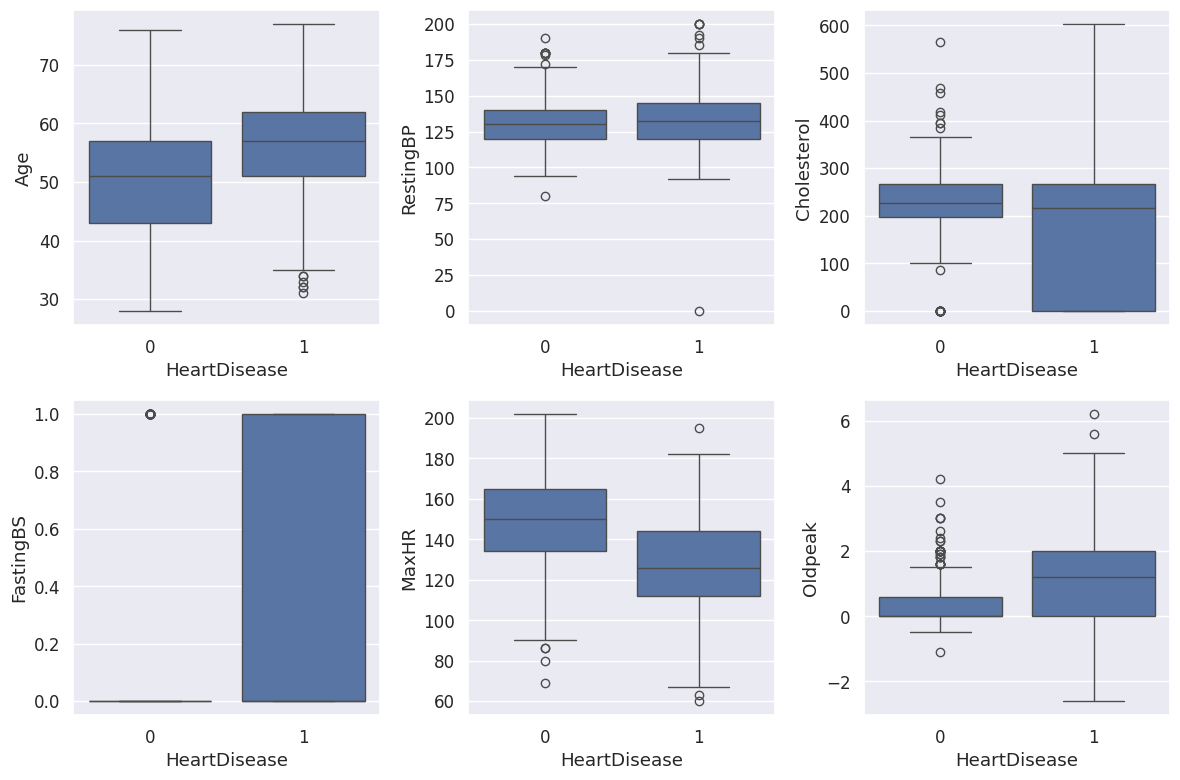

In [ ]:
plt.figure(figsize = (12,8))
for i, col in enumerate(numeric_cols,1):
  plt.subplot(2,3,i)
  sns.boxplot(x = target_col, y = col, data = df)

plt.tight_layout()
plt.show()

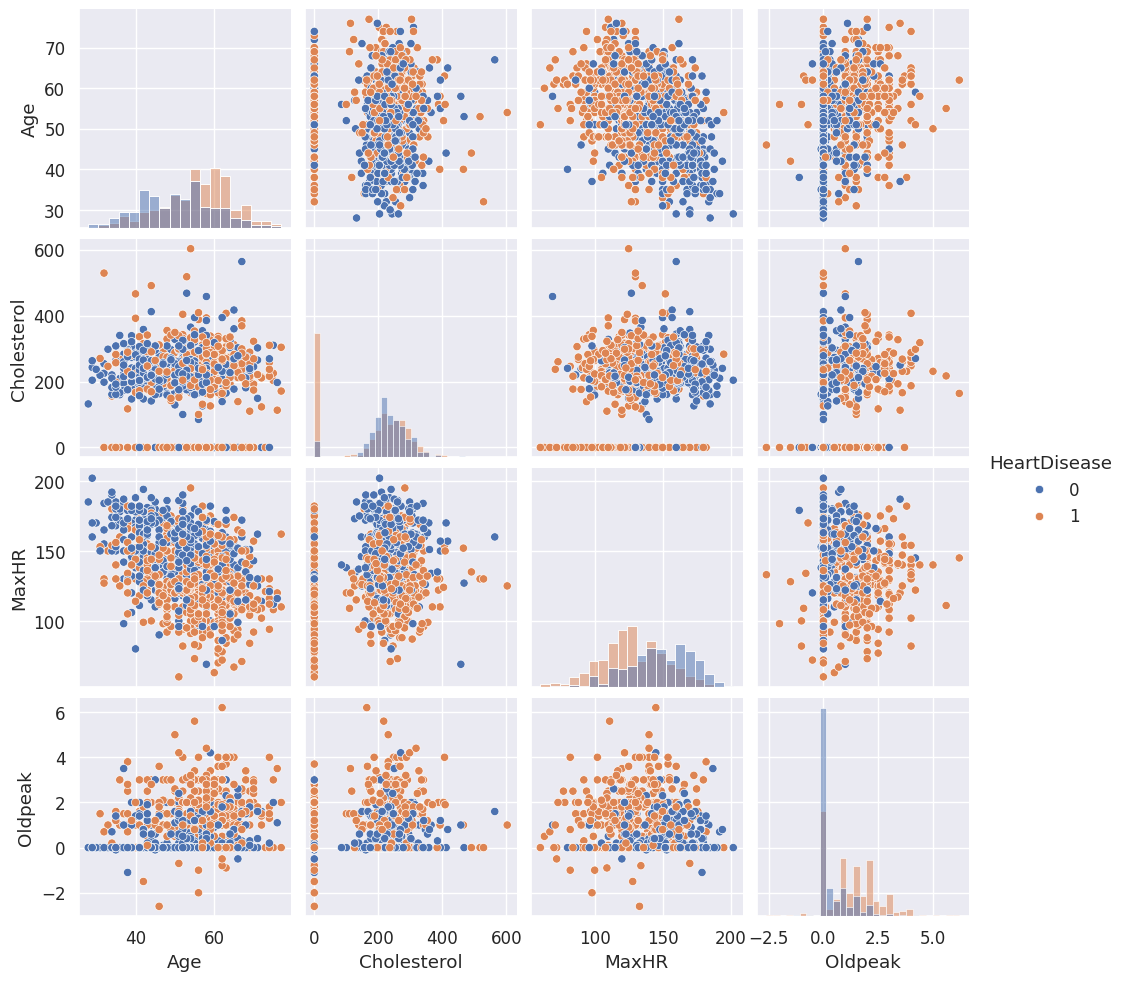

In [ ]:
sns.pairplot(df[['Age', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']], hue = 'HeartDisease', diag_kind='hist')
plt.show()

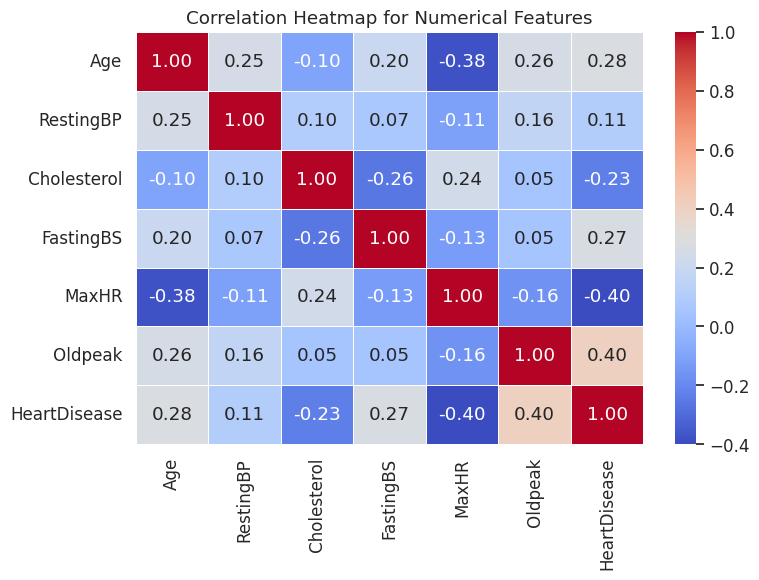

In [ ]:
corr_matrix = df[numeric_cols + [target_col]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot = True, cmap  = "coolwarm", fmt = ".2f", linewidths=0.5)
plt.title("Correlation Heatmap for Numerical Features")
plt.tight_layout()
plt.show()

In [ ]:
corr_matrix[target_col].sort_values(ascending=False)

,HeartDisease
HeartDisease,1.000000
Oldpeak,0.403951
Age,0.282039
FastingBS,0.267291
RestingBP,0.107589
Cholesterol,-0.232741
MaxHR,-0.400421



Proportion of HeartDisease within Sex


HeartDisease,0,1
Sex,,
F,0.740933,0.259067
M,0.368276,0.631724


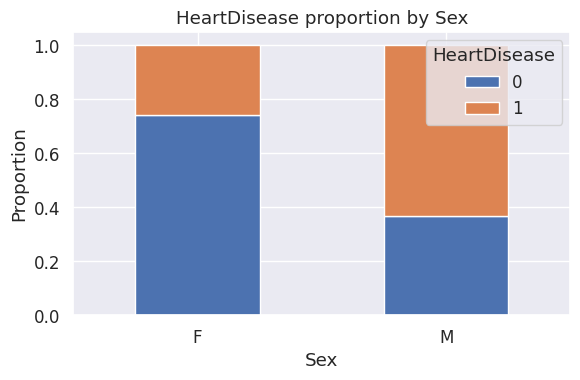


Proportion of HeartDisease within ChestPainType


HeartDisease,0,1
ChestPainType,,
ASY,0.209677,0.790323
ATA,0.861272,0.138728
NAP,0.645320,0.354680
TA,0.565217,0.434783


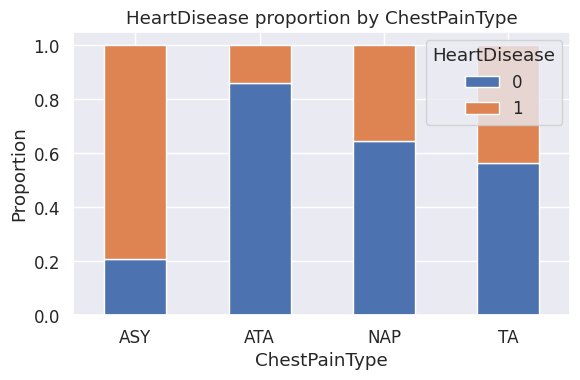


Proportion of HeartDisease within RestingECG


HeartDisease,0,1
RestingECG,,
LVH,0.436170,0.563830
Normal,0.483696,0.516304
ST,0.342697,0.657303


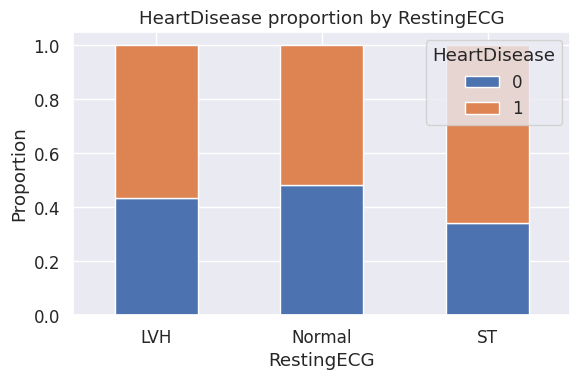


Proportion of HeartDisease within ExerciseAngina


HeartDisease,0,1
ExerciseAngina,,
N,0.648995,0.351005
Y,0.148248,0.851752


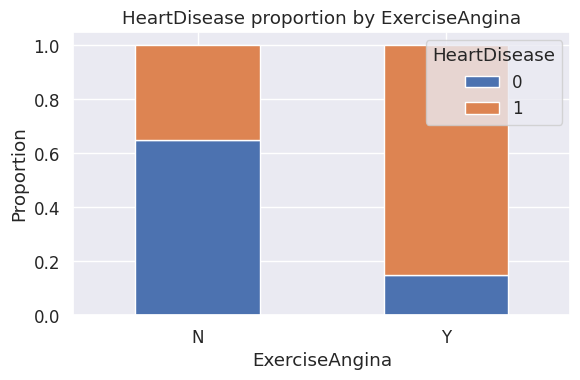


Proportion of HeartDisease within ST_Slope


HeartDisease,0,1
ST_Slope,,
Down,0.222222,0.777778
Flat,0.171739,0.828261
Up,0.802532,0.197468


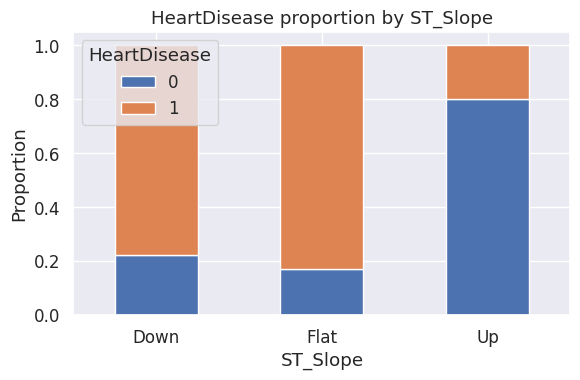

In [ ]:
for c in categorical_cols:
  ct = pd.crosstab(df[c], df[target_col], normalize="index")
  print(f"\nProportion of HeartDisease within {c}")
  display(ct)

  ct.plot(kind= "bar", stacked = True, figsize = (6,4))
  plt.title(f"HeartDisease proportion by {c}")
  plt.ylabel("Proportion")
  plt.xticks(rotation= 0)
  plt.tight_layout()
  plt.show()